# Low-rank probability-matrix diagnostics

The reusable code now lives in the `qelm_rank` package. This notebook is
just a runnable workspace for toy checks, sweeps, and real `P` workflows.


In [2]:
import numpy as np

from qelm_rank import (
    add_markov_slack_columns,
    compare_q3_q5_collapse,
    deterministic_cp_scaling_fit,
    run_random_quantum_scaling_sweep,
    plot_random_quantum_scaling,
    fit_random_quantum_scaling_laws,
    generate_haar_random_pure_states,
    generate_random_rank1_povm,
    make_toy_P_for_sweep,
    plot_Xi21_markov_check,
    plot_failure_rates,
    plot_metric_vs_kappa,
    plot_metric_vs_predictors,
    probability_matrix_from_povm_states,
    plot_sweep_diagnostics,
    run_dimension_sweep,
    run_single_P_workflow,
    run_toy_low_rank_sweep,
)

SUMMARY_COLUMNS = [
    "q",
    "p",
    "lambda_min_C22",
    "c_p",
    "kappa_q3",
    "E_Y_shape",
    "D_Y_p90",
    "E_Q_shape",
    "D_Q_p90",
    "E_R_schur_shape",
    "D_R_schur_p90",
    "E_full_schur_lead_shape",
    "D_lead_schur_p90",
    "D_full_schur_p90",
    "S22_pinv_rate",
]


## Random Haar states and rank-1 POVM

This quick example builds a POVM from a random isometry, samples Haar random pure states, and forms `P[a, i] = Tr(mu_a rho_i)`.


In [3]:
rng = np.random.default_rng(7)
d = 2
nout = 5
ntr = 8

effects = generate_random_rank1_povm(nout=nout, dim=d, rng=rng)
states = generate_haar_random_pure_states(num_states=ntr, dim=d, rng=rng)
P_random = probability_matrix_from_povm_states(effects, states)

print(P_random.shape)
print(P_random.sum(axis=0))
display(P_random.round(4))


(5, 8)
[1. 1. 1. 1. 1. 1. 1. 1.]


array([[0.0102, 0.0485, 0.0641, 0.0317, 0.0323, 0.0445, 0.0049, 0.0213],
       [0.1269, 0.0032, 0.1081, 0.0436, 0.1711, 0.0357, 0.2983, 0.1873],
       [0.031 , 0.0492, 0.1736, 0.0434, 0.1002, 0.0876, 0.1344, 0.0774],
       [0.4919, 0.2379, 0.1321, 0.3194, 0.4111, 0.2031, 0.5492, 0.4916],
       [0.3401, 0.6613, 0.5221, 0.5619, 0.2853, 0.6291, 0.0132, 0.2223]])

## Deterministic scaling for random quantum `P`

This sweep varies `nout` and `ntr` for small `d`, with `nout >> d^2`, `ntr >> d^2`, and `ntr > nout`. It records only deterministic block quantities, so it is much cheaper than shot-noise trials.


rank_C22: 4 q_dim: 4 lam_max: 0.01820637895503921 bound: 0.07282551582015684 trace: 0.06062101037503917
rank_C22: 4 q_dim: 4 lam_max: 0.021621029510741307 bound: 0.08648411804296523 trace: 0.07845614793543654
rank_C22: 4 q_dim: 4 lam_max: 0.02454506864127659 bound: 0.09818027456510636 trace: 0.0754174173348486
rank_C22: 4 q_dim: 4 lam_max: 0.022053314183608914 bound: 0.08821325673443565 trace: 0.07151127336027441
rank_C22: 4 q_dim: 4 lam_max: 0.01994967612064551 bound: 0.07979870448258204 trace: 0.05830013987379913
rank_C22: 4 q_dim: 4 lam_max: 0.0271566350078885 bound: 0.108626540031554 trace: 0.08349536311022461
rank_C22: 4 q_dim: 4 lam_max: 0.027278874110763664 bound: 0.10911549644305465 trace: 0.07632683191221407
rank_C22: 4 q_dim: 4 lam_max: 0.026230878512511845 bound: 0.10492351405004738 trace: 0.08608612056285872
rank_C22: 4 q_dim: 4 lam_max: 0.026534080485576473 bound: 0.10613632194230589 trace: 0.08155914600264218
rank_C22: 4 q_dim: 4 lam_max: 0.022206114597421486 bound: 0.088

,d,nout,ntr,nout_over_d2,ntr_over_d2,ntr_over_nout,lambda_min_C22,lambda_max_C22,trace_C22,delta_shape,c_p
0,6,40,37,1.111111,1.027778,0.925,0.012074,0.018206,0.060621,47.072265,0.013128
1,6,40,37,1.111111,1.027778,0.925,0.016848,0.021621,0.078456,47.072265,0.010601
2,6,40,37,1.111111,1.027778,0.925,0.014696,0.024545,0.075417,47.072265,0.008582
3,6,40,37,1.111111,1.027778,0.925,0.014788,0.022053,0.071511,47.072265,0.007870
4,6,40,37,1.111111,1.027778,0.925,0.009029,0.019950,0.058300,47.072265,0.012900
...,...,...,...,...,...,...,...,...,...,...,...
145,6,800,128,22.222222,3.555556,0.160,0.000241,0.003027,0.941660,11.701963,0.000852
146,6,800,128,22.222222,3.555556,0.160,0.000183,0.003218,0.940673,11.701963,0.000982
147,6,800,128,22.222222,3.555556,0.160,0.000240,0.003376,0.942019,11.701963,0.001104
148,6,800,128,22.222222,3.555556,0.160,0.000227,0.002976,0.940607,11.701963,0.000889


,d,quantity,nout_power,ntr_power,log_intercept,num_rows
0,6,lambda_min_C22,-1.424308,0.188593,0.041773,150
1,6,lambda_max_C22,-0.635210,-0.176176,-0.545862,150
2,6,delta_shape,0.853263,-3.150559,11.758551,150
3,6,c_p,-0.721743,-0.290241,-0.612804,150


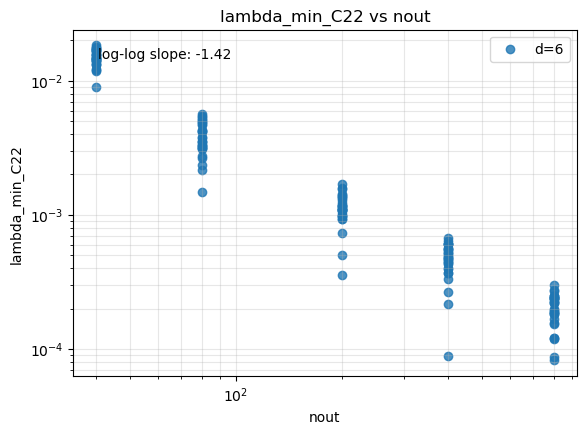

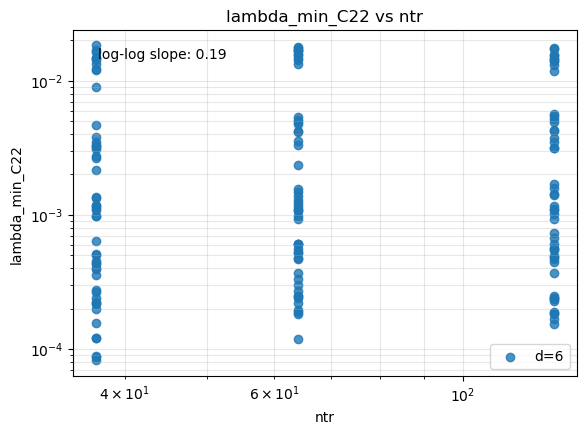

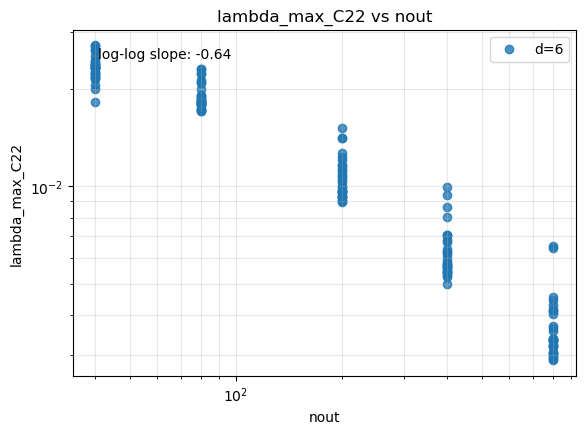

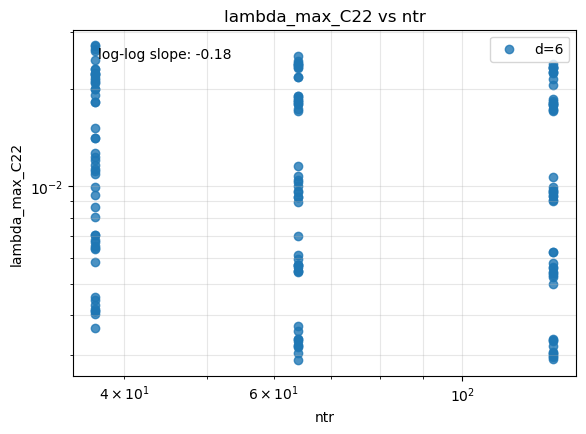

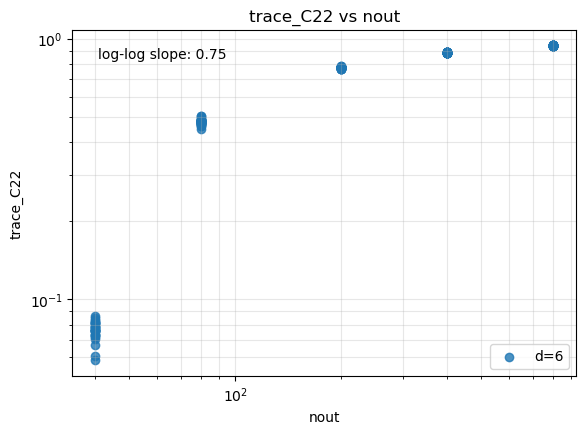

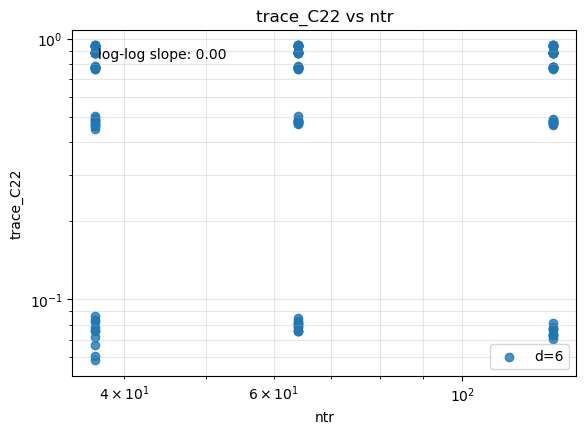

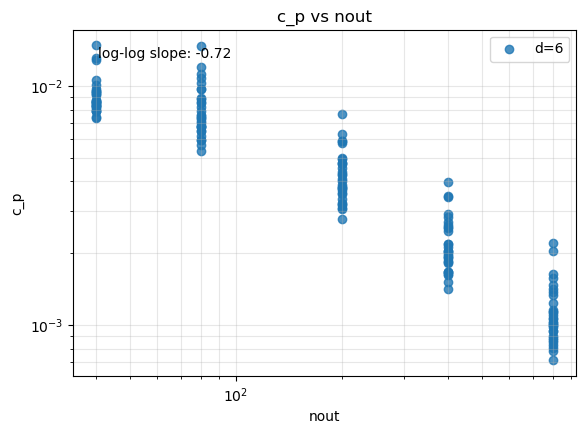

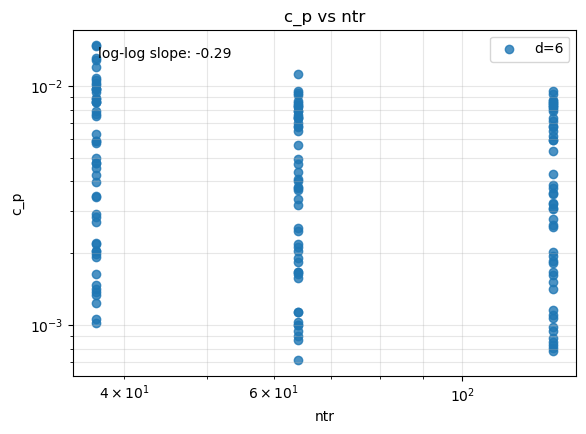

In [3]:
quantum_scaling_df = run_random_quantum_scaling_sweep(
    d_values=[6],
    nout_values=[40, 80, 200, 400, 800],
    ntr_values=[37, 64, 128],
    repetitions=10,
    seed=21,
    progress=False,
)

display(quantum_scaling_df[[
    "d",
    "nout",
    "ntr",
    "nout_over_d2",
    "ntr_over_d2",
    "ntr_over_nout",
    "lambda_min_C22",
    "lambda_max_C22",
    "trace_C22",
    "delta_shape",
    "c_p",
]])

quantum_scaling_fit = fit_random_quantum_scaling_laws(quantum_scaling_df)
display(quantum_scaling_fit)

plot_random_quantum_scaling(quantum_scaling_df)



## Quick toy sweep

This gives a multi-row dataframe and nontrivial plots without requiring a
large dimension sweep.


In [ ]:
toy_trial_df, toy_summary = run_toy_low_rank_sweep(
    q_values=(4, 8),
    p_values=(500, 1000, 2500, 5000),
    d=2,
    N=1000,
    trials=30,
    noise_model="gaussian",
    seed=1,
)

display(toy_summary[[col for col in SUMMARY_COLUMNS if col in toy_summary.columns]])

plot_metric_vs_predictors(toy_summary, quantile="p90")
plot_metric_vs_kappa(
    toy_summary,
    kappa_col="kappa_q3",
    metric_base="D_full_schur",
    title="Full Schur diagnostic vs kappa_q3",
)


## Failure-rate check


In [ ]:
toy_failure_df = plot_failure_rates(
    toy_trial_df,
    thresholds={
        "D_Y": 0.10,
        "D_Q": 0.10,
        "D_R_schur": 0.10,
        "D_full_schur": 0.10,
    },
    group_cols=("q", "p"),
)
display(toy_failure_df)


## Optional dimension sweep

Set `RUN_DIMENSION_SWEEP = True` when you want the heavier sweep.


In [ ]:
RUN_DIMENSION_SWEEP = False

if RUN_DIMENSION_SWEEP:
    trials_df_q3, summary_q3, det_q3 = run_dimension_sweep(
        make_P_fn=make_toy_P_for_sweep,
        d_values=[2],
        q_values=[4, 6, 8, 10],
        kappa_values=[0.1, 0.3, 1.0, 3.0, 10.0],
        scaling="q3",
        trials=50,
        N=1000,
        noise_model="gaussian",
        seed=123,
    )

    plot_sweep_diagnostics(summary_q3, det_q3, scaling="q3", quantile="p90")
    compare_q3_q5_collapse(summary_q3, quantile="p90")
    display(deterministic_cp_scaling_fit(det_q3))

    summary_q3 = add_markov_slack_columns(summary_q3)
    display(summary_q3[[
        "r",
        "q",
        "p",
        "B_cp_qminus1",
        "a_p_cp_qminus1",
        "markov_fail_bound_cp_qminus1",
        "a_p_squared_B_cp_qminus1",
    ]])
    plot_Xi21_markov_check(trials_df_q3)


## Real probability matrix workflow

Replace `P` and `d` with your actual probability matrix and Hilbert
dimension, then uncomment the call below.


In [ ]:
# P = probability_matrix_from_povm_states(povm_effects=effects, states=states)
#
# blocks, trial_df, summary = run_single_P_workflow(
#     P=P,
#     r=d**2,
#     N=1000,
#     trials=200,
#     noise_model="multinomial",
#     seed=12345,
# )
